In [1]:
import joblib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, precision_recall_curve

from transformers import Resampler, BandPassFilter, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor

In [2]:
def show_precision_recall_curve(y_true, y_proba, punto_corte=0.5):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)

    plt.plot(thr, rec[:-1], label='recall')
    plt.plot(thr, prec[:-1], label='precision')
    plt.xlabel('Punto de corte')
    plt.vlines(punto_corte, 0, 1, colors='red', linestyles='dashed', label='corte')
    plt.grid()
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.legend()
    plt.show()

def show_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Matriz de Confusión');

## Pipelines

Se pueden probar la sustración espectral o wavelet denoising

In [3]:
pipeline_melspec = Pipeline([
    ('resampler', Resampler()),
    ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('padder', SpectrogramPadder()),
    ('flatten', FlattenTransformer())
])

pipeline_features = Pipeline([
    ('resampler', Resampler()),
    ('bandpass', BandPassFilter()),
    ('feature_extractor', FeatureExtractor())
])

## Audios de validación

### propios

In [4]:
path = './audios_propios/ciclos_energy_based'
files = os.listdir(path)

In [5]:
paths = [os.path.join(path, f) for f in files]

In [6]:
X_propios_melspec = pipeline_melspec.fit_transform(paths)

In [7]:
X_propios_features = pipeline_features.fit_transform(paths)

### coswara

Hay que segmentarlos!!!

## ciclos_f2_r

### melspec_rf

In [8]:
test_data = np.load(f'./dataset/ciclos_f2_r/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [9]:
melspec_rf = joblib.load('./modelos/ciclos_f2_r/melspec_rf.pkl')

In [10]:
y_pred = melspec_rf.predict(X_test)
y_pred_proba = melspec_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.86      0.80       180
           1       0.74      0.58      0.65       123

    accuracy                           0.75       303
   macro avg       0.74      0.72      0.72       303
weighted avg       0.75      0.75      0.74       303



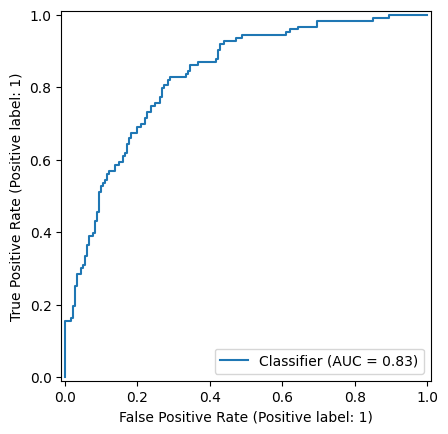

In [11]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

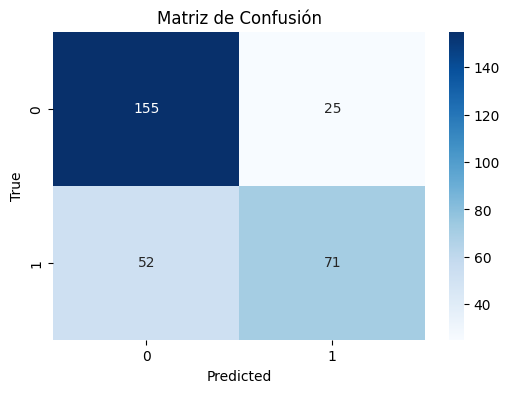

In [12]:
show_confusion_matrix(y_test, y_pred)

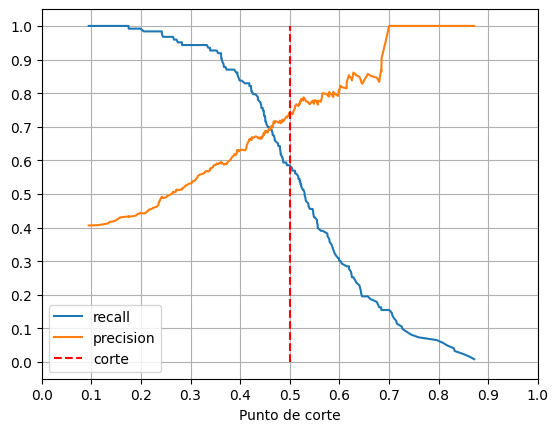

In [13]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

In [14]:
probas_propios = melspec_rf.predict_proba(X_propios_melspec)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})

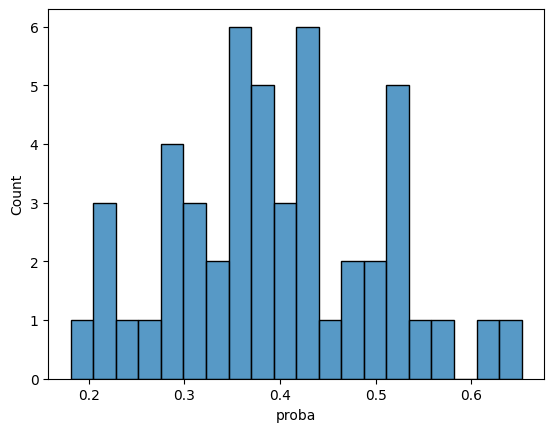

In [15]:
sns.histplot(df_probas, x='proba', bins=20);

In [16]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.477425
1,respiracion1_ciclo_2.wav,0.389067
2,respiracion1_ciclo_3.wav,0.652531
3,respiracion1_ciclo_4.wav,0.289295
4,respiracion1_ciclo_5.wav,0.622107
5,respiracion1_ciclo_6.wav,0.432146
6,respiracion1_ciclo_7.wav,0.525876
7,respiracion2_ciclo_1.wav,0.404698
8,respiracion2_ciclo_2.wav,0.559189
9,respiracion2_ciclo_3.wav,0.523123


### features_rf

In [17]:
test_data = np.load(f'./dataset/ciclos_f2_r/test_features.npz')
X_test = test_data['X']
y_test = test_data['y']

In [18]:
feat_rf = joblib.load('./modelos/ciclos_f2_r/features_rf.pkl')

In [19]:
y_pred = feat_rf.predict(X_test)
y_pred_proba = feat_rf.predict_proba(X_test)[:, 1]

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       180
           1       0.79      0.65      0.71       123

    accuracy                           0.79       303
   macro avg       0.79      0.77      0.77       303
weighted avg       0.79      0.79      0.78       303



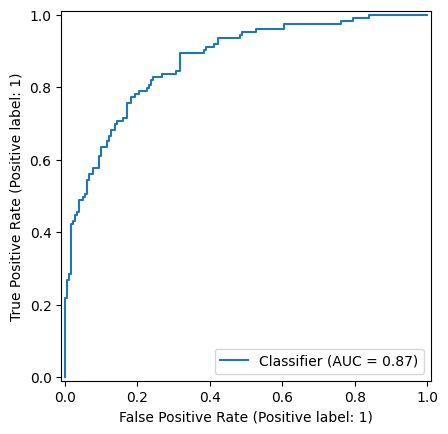

In [21]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

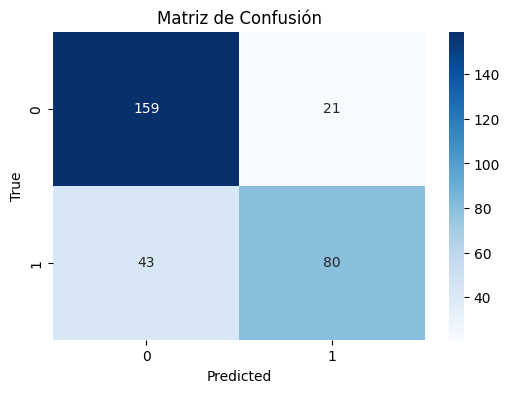

In [22]:
show_confusion_matrix(y_test, y_pred)

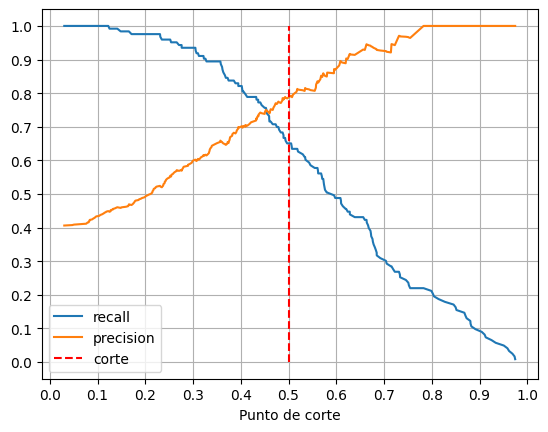

In [23]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

In [24]:
probas_propios = feat_rf.predict_proba(X_propios_features)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})

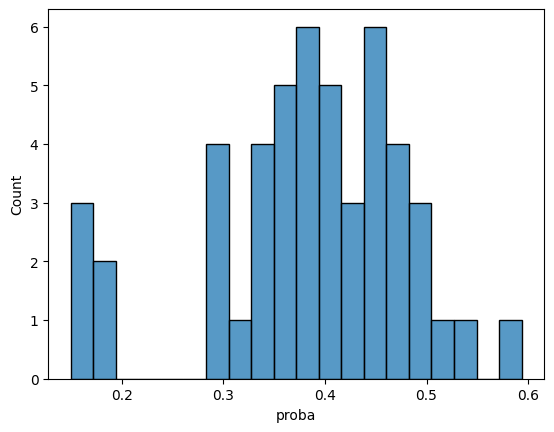

In [25]:
sns.histplot(df_probas, x='proba', bins=20);

In [26]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.380372
1,respiracion1_ciclo_2.wav,0.469776
2,respiracion1_ciclo_3.wav,0.457683
3,respiracion1_ciclo_4.wav,0.441137
4,respiracion1_ciclo_5.wav,0.505143
5,respiracion1_ciclo_6.wav,0.448040
6,respiracion1_ciclo_7.wav,0.374258
7,respiracion2_ciclo_1.wav,0.419447
8,respiracion2_ciclo_2.wav,0.490945
9,respiracion2_ciclo_3.wav,0.376534


## ciclos_f1_r

### melspec_rf

In [27]:
test_data = np.load(f'./dataset/ciclos_f1_r/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [28]:
melspec_rf = joblib.load('./modelos/ciclos_f1_r/melspec_rf.pkl')

In [29]:
y_pred = melspec_rf.predict(X_test)
y_pred_proba = melspec_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.55      0.62       398
           1       0.69      0.82      0.75       484

    accuracy                           0.70       882
   macro avg       0.70      0.69      0.69       882
weighted avg       0.70      0.70      0.69       882



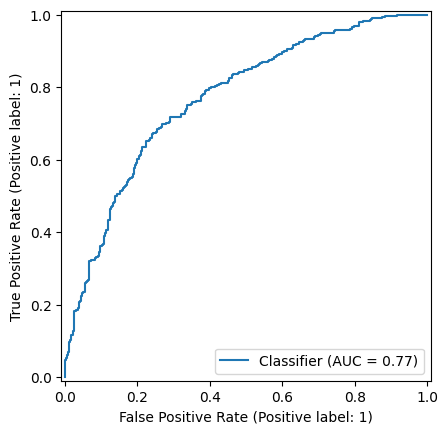

In [61]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

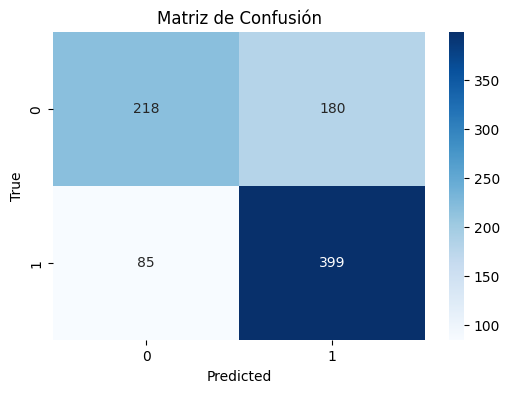

In [30]:
show_confusion_matrix(y_test, y_pred)

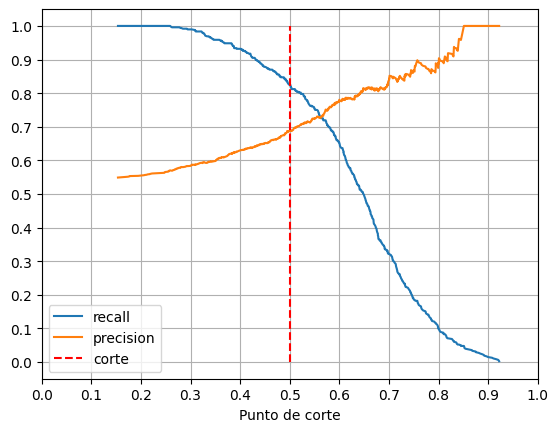

In [31]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

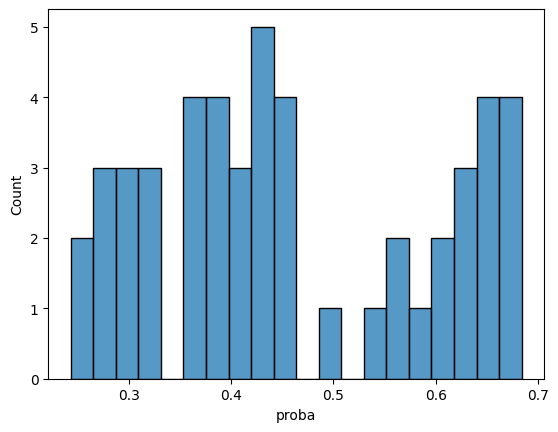

In [32]:
probas_propios = melspec_rf.predict_proba(X_propios_melspec)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})
sns.histplot(df_probas, x='proba', bins=20);

In [33]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.550070
1,respiracion1_ciclo_2.wav,0.390604
2,respiracion1_ciclo_3.wav,0.667546
3,respiracion1_ciclo_4.wav,0.279778
4,respiracion1_ciclo_5.wav,0.599665
5,respiracion1_ciclo_6.wav,0.450050
6,respiracion1_ciclo_7.wav,0.650959
7,respiracion2_ciclo_1.wav,0.424994
8,respiracion2_ciclo_2.wav,0.651980
9,respiracion2_ciclo_3.wav,0.670827


### features_rf

In [34]:
test_data = np.load(f'./dataset/ciclos_f1_r/test_features.npz')
X_test = test_data['X']
y_test = test_data['y']

In [35]:
feat_rf = joblib.load('./modelos/ciclos_f1_r/features_rf.pkl')

In [36]:
y_pred = feat_rf.predict(X_test)
y_pred_proba = feat_rf.predict_proba(X_test)[:, 1]

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.58      0.65       398
           1       0.70      0.82      0.76       484

    accuracy                           0.71       882
   macro avg       0.71      0.70      0.70       882
weighted avg       0.71      0.71      0.71       882



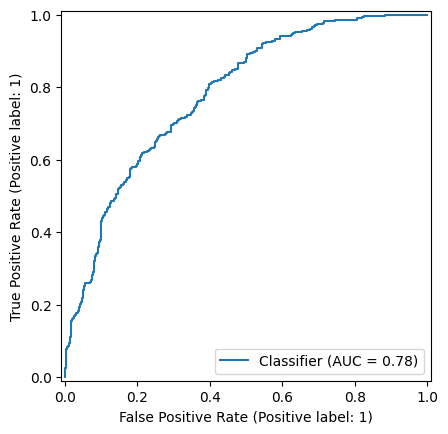

In [38]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

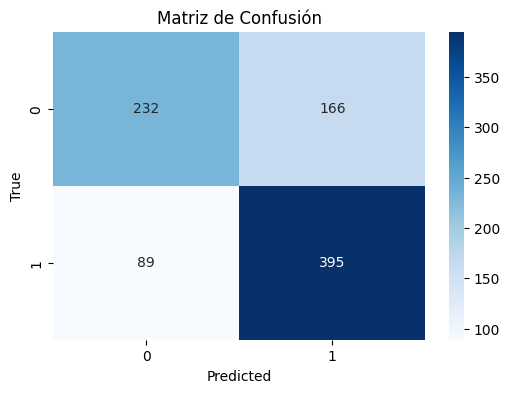

In [39]:
show_confusion_matrix(y_test, y_pred)

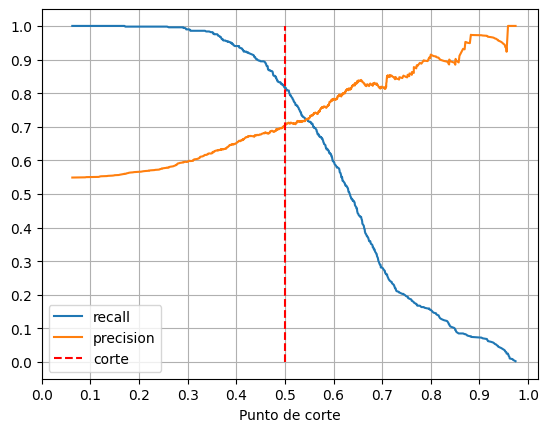

In [40]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

In [41]:
probas_propios = feat_rf.predict_proba(X_propios_features)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})

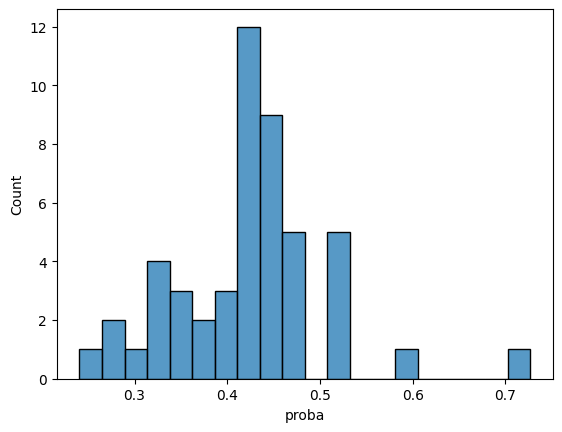

In [42]:
sns.histplot(df_probas, x='proba', bins=20);

In [43]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.433406
1,respiracion1_ciclo_2.wav,0.267171
2,respiracion1_ciclo_3.wav,0.436858
3,respiracion1_ciclo_4.wav,0.527335
4,respiracion1_ciclo_5.wav,0.380148
5,respiracion1_ciclo_6.wav,0.450431
6,respiracion1_ciclo_7.wav,0.472331
7,respiracion2_ciclo_1.wav,0.420458
8,respiracion2_ciclo_2.wav,0.445122
9,respiracion2_ciclo_3.wav,0.361434


## ciclos_c_r

### melspec_rf

In [76]:
test_data = np.load(f'./dataset/ciclos_c_r/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [77]:
melspec_rf = joblib.load('./modelos/ciclos_c_r/melspec_rf.pkl')

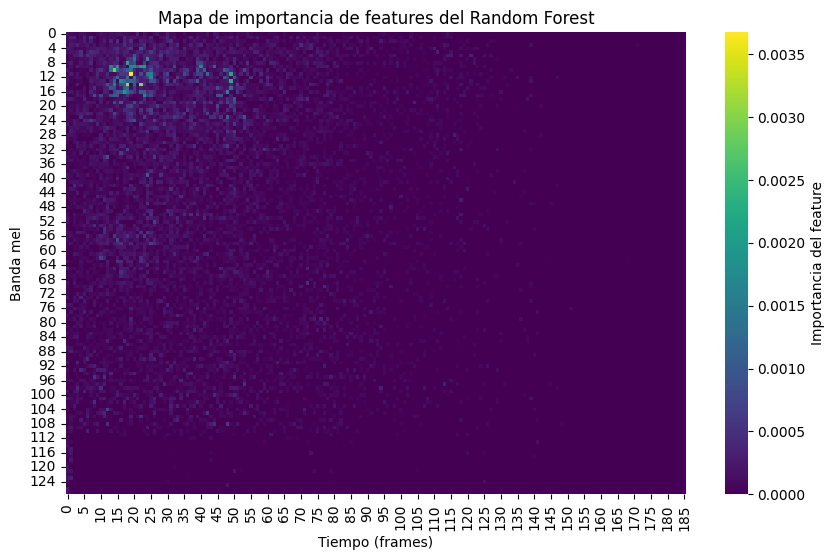

In [45]:
importances = melspec_rf.feature_importances_

n_mels = 128
n_frames = importances.shape[0] // n_mels

importance_img = importances.reshape((n_mels, n_frames))

plt.figure(figsize=(10, 6))
sns.heatmap(
    importance_img,
    cmap="viridis",
    cbar_kws={'label': 'Importancia del feature'},
)
plt.xlabel("Tiempo (frames)")
plt.ylabel("Banda mel")
plt.title("Mapa de importancia de features del Random Forest")
plt.show()

In [79]:
y_pred = melspec_rf.predict(X_test)
y_pred_proba = melspec_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.67      0.68       663
           1       0.67      0.68      0.67       633

    accuracy                           0.68      1296
   macro avg       0.68      0.68      0.68      1296
weighted avg       0.68      0.68      0.68      1296



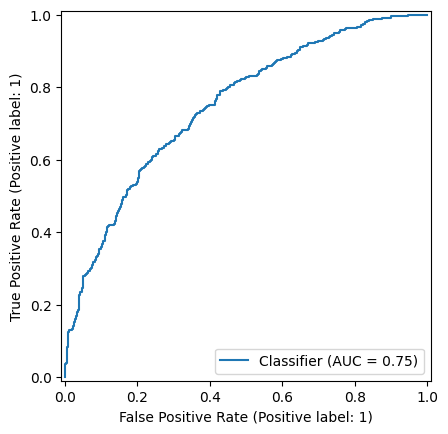

In [80]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

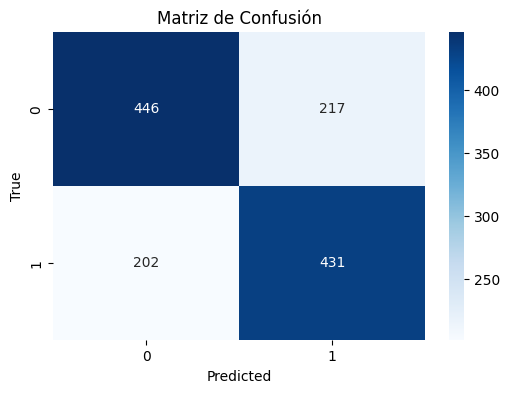

In [81]:
show_confusion_matrix(y_test, y_pred)

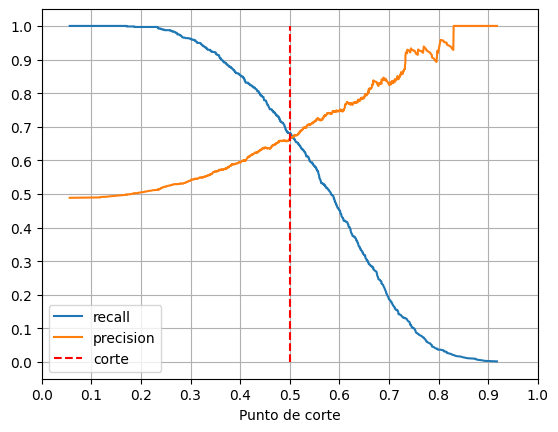

In [82]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

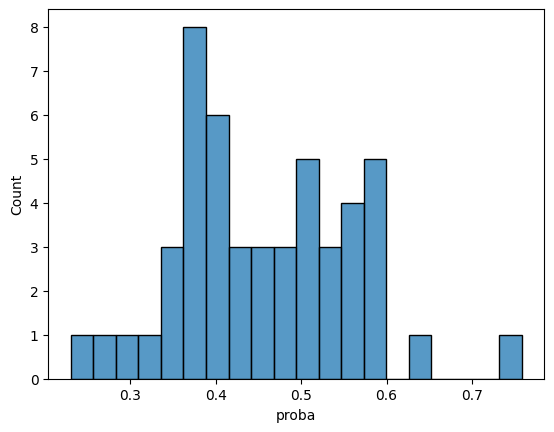

In [83]:
probas_propios = melspec_rf.predict_proba(X_propios_melspec)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})
sns.histplot(df_probas, x='proba', bins=20);

In [84]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.561640
1,respiracion1_ciclo_2.wav,0.393952
2,respiracion1_ciclo_3.wav,0.578444
3,respiracion1_ciclo_4.wav,0.375044
4,respiracion1_ciclo_5.wav,0.513850
5,respiracion1_ciclo_6.wav,0.464392
6,respiracion1_ciclo_7.wav,0.534760
7,respiracion2_ciclo_1.wav,0.430290
8,respiracion2_ciclo_2.wav,0.461061
9,respiracion2_ciclo_3.wav,0.558940


### features_rf

In [85]:
test_data = np.load(f'./dataset/ciclos_c_r/test_features.npz')
X_test = test_data['X']
y_test = test_data['y']

In [86]:
feat_rf = joblib.load('./modelos/ciclos_c_r/features_rf.pkl')

In [87]:
y_pred = feat_rf.predict(X_test)
y_pred_proba = feat_rf.predict_proba(X_test)[:, 1]

In [88]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76       663
           1       0.75      0.75      0.75       633

    accuracy                           0.76      1296
   macro avg       0.76      0.76      0.76      1296
weighted avg       0.76      0.76      0.76      1296



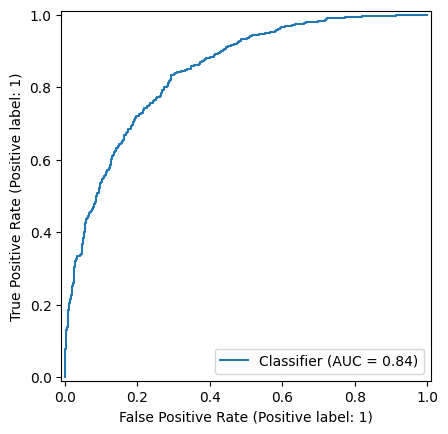

In [89]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

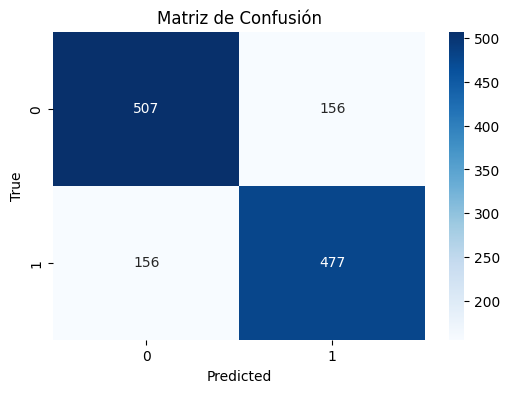

In [90]:
show_confusion_matrix(y_test, y_pred)

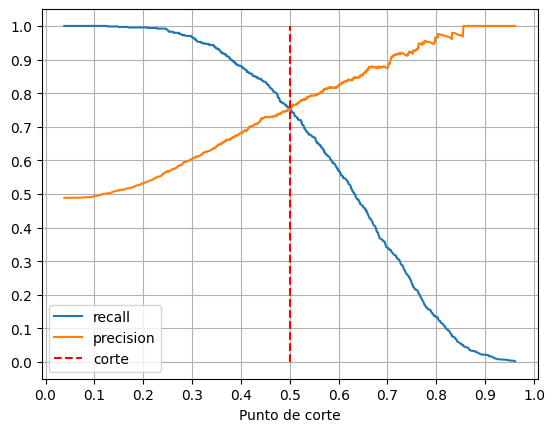

In [91]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

In [92]:
probas_propios = feat_rf.predict_proba(X_propios_features)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})

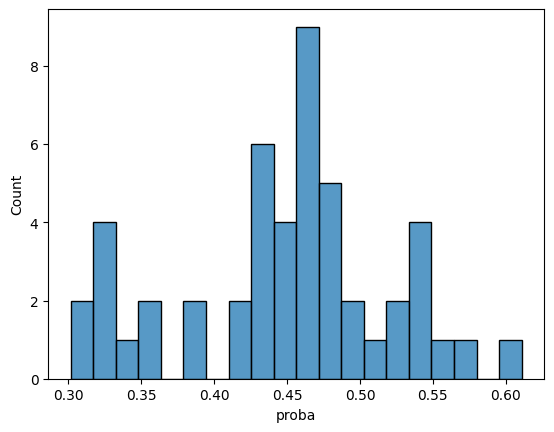

In [93]:
sns.histplot(df_probas, x='proba', bins=20);

In [94]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.460020
1,respiracion1_ciclo_2.wav,0.477061
2,respiracion1_ciclo_3.wav,0.544016
3,respiracion1_ciclo_4.wav,0.545212
4,respiracion1_ciclo_5.wav,0.523146
5,respiracion1_ciclo_6.wav,0.442981
6,respiracion1_ciclo_7.wav,0.514214
7,respiracion2_ciclo_1.wav,0.610806
8,respiracion2_ciclo_2.wav,0.565389
9,respiracion2_ciclo_3.wav,0.498413
